# Анасамбли машинного обучения. Часть 1. 



# 1)-3) Загрузка и подготовка данных, разделение на тестовую и обучающие выборки

1. Выбор набора данных

Для выполнения лабораторной работы выбран датасет Bank Marketing Dataset. Он содержит данные о маркетинговой кампании банка. Задача относится к бинарной классификации: предсказать, откроет ли клиент депозит (deposit: yes/no). Датасет включает 11162 записи и 17 признаков.

2. Предобработка данных

Пропуски в данных отсутствуют. Целевая переменная deposit преобразована в бинарный формат (1 = yes, 0 = no). Для категориальных признаков (job, marital, education, default, housing, loan, contact, month, poutcome) применен One-Hot Encoding. После преобразования число признаков увеличилось до 42. Числовые признаки стандартизированы с помощью StandardScaler.

3. Разделение на обучающую и тестовую выборки

Данные разделены в соотношении 80/20 с сохранением пропорций классов (stratify=y). Обучающая выборка содержит 8 929 объектов, тестовая 2233 объекта. Классы сбалансированы: доля положительных ответов составляет приимерно 47% в обеих выборках.

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
from operator import itemgetter

df = pd.read_csv('bank.csv')


print("Первичный анализ данных:")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о столбцах:")
print(df.info())

print("\nПроверка на пропуски:")
print(df.isnull().sum().sum(), "пропусков найдено")

print("\nЦелевая переменная 'deposit':")
print(df['deposit'].value_counts())

#кодирование категориальных признаков и целевой переменной
print("Предобработка данных:")


#копия датафрейма для обработки
df_processed = df.copy()

#кодируем целевую переменную yes=1, no=0
df_processed['deposit'] = df_processed['deposit'].map({'yes': 1, 'no': 0})

#выделяем категориальные признаки (object)
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные признаки: {categorical_cols}")

#one-hot encoding для категориальных признаков
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

print(f"После One-Hot Encoding размер датасета: {df_processed.shape}")

#hазделяем на признаки (x) и целевую переменную (y)
X = df_processed.drop('deposit', axis=1)
y = df_processed['deposit']

#масштабирование признаков 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Признаки масштабированы с помощью StandardScaler")

#разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  #сохраняем пропорции классов
)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")
print(f"Количество признаков: {X_train.shape[1]}")
print(f"\nРаспределение классов в обучающей выборке:")
print(f"0 (no):  {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train):.1%})")
print(f"1 (yes): {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train):.1%})")
print(f"\nРаспределение классов в тестовой выборке:")
print(f"0 (no):  {sum(y_test == 0)} ({sum(y_test == 0)/len(y_test):.1%})")
print(f"1 (yes): {sum(y_test == 1)} ({sum(y_test == 1)/len(y_test):.1%})")



Первичный анализ данных:
Размер датасета: 11162 строк, 17 столбцов

Первые 5 строк:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  

Информация о с

# 4) Обучение ансамблевых моделей 

## Модели группы бэггинга

На данном этапе были обучены две ансамблевые модели, относящиеся к группе методов бэггинга. Основная идея этих методов заключается в построении ансамбля из нескольких базовых моделей, каждая из которых обучается на случайной подвыборке исходных данных, полученной методом бутстрэпа (выборка с возвращением). 

1. Bagging Classifier (бэггинг)

Первой моделью был обучен чистый Bagging Classifier. В качестве базового алгоритма использовалось решающее дерево (DecisionTreeClassifier). Количество базовых моделей в ансамбле составило 100 (n_estimators=100). Каждое дерево обучалось на бутстрэп-подвыборке из тренировочных данных, после чего итоговый прогноз формировался путем голосования большинством.

2. Random Forest (случайный лес)

Второй моделью стал Random Forest Classifier (усовершенствованная версия бэггинга для деревьев решений). Помимо использования бутстрэп-выборок, случайный лес добавляет дополнительный элемент случайности: при каждом разбиении узла дерева рассматривается не полный набор признаков, а лишь случайное подмножество из них. Это уменьшает корреляцию между отдельными деревьями ансамбля и ещё сильнее снижает дисперсию итоговой модели. Количество деревьев также было установлено равным 100.

С помощью функции draw_feature_importances построен график важности признаков для случайного леса, который показывает, какие факторы вносят наибольший вклад в прогнозирование открытия депозита.


Модель 1: Bagging Classifier
Модель обучена. Время обучения: 3.23 сек

Модель 2: Random Forest Classifier
Модель обучена. Время обучения: 0.21 сек
Важность признаков (Random Forest)


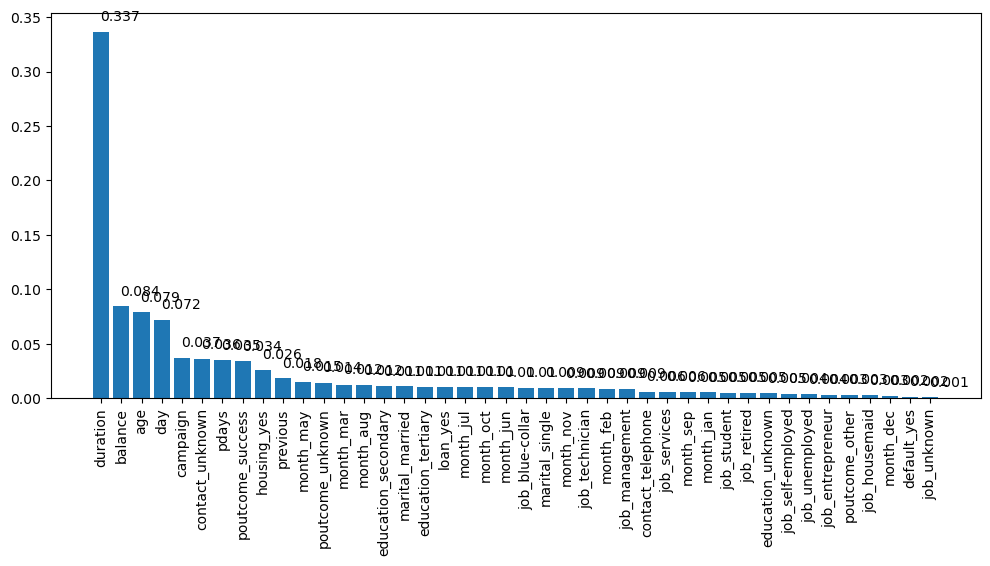

In [6]:
#функция из лекции для визуализации важности признаков
def draw_feature_importances(tree_model, X_dataset, figsize=(10,5)):
    #сортировка значений важности признаков по убыванию
    list_to_sort = list(zip(X_dataset.columns.values, tree_model.feature_importances_))
    sorted_list = sorted(list_to_sort, key=itemgetter(1), reverse = True)
    #названия признаков
    labels = [x for x,_ in sorted_list]
    #важности признаков
    data = [x for _,x in sorted_list]
    #вывод графика
    fig, ax = plt.subplots(figsize=figsize)
    ind = np.arange(len(labels))
    plt.bar(ind, data)
    plt.xticks(ind, labels, rotation='vertical')
    #вывод значений
    for a,b in zip(ind, data):
        plt.text(a-0.05, b+0.01, str(round(b,3)))
    plt.show()
    return labels, data


#модель 1: бэггинг
print("\nМодель 1: Bagging Classifier")

start_time = time.time()

bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

bagging_clf.fit(X_train, y_train)
train_time_bagging = time.time() - start_time

print(f"Модель обучена. Время обучения: {train_time_bagging:.2f} сек")

#модель 2: случайный лес

print("\nМодель 2: Random Forest Classifier")

start_time = time.time()

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)
train_time_rf = time.time() - start_time

print(f"Модель обучена. Время обучения: {train_time_rf:.2f} сек")



#график важности признаков для Random Forest
print("Важность признаков (Random Forest)")

#создаем фрейм с именами признаков
X_df = pd.DataFrame(X_train, columns=X.columns)
labels, data = draw_feature_importances(rf_clf, X_df, figsize=(12,5))

## AdaBoost и градиентный бустинг

На данном этапе были обучены модели AdaBoost и градиентного бустинга:

3. AdaBoost Classifier

AdaBoost (Adaptive Boosting)-это алгоритм бустинга, который последовательно обучает базовые модели (в данном случае решающие деревья с глубиной 1). На каждой итерации алгоритм увеличивает вес тех объектов, на которых предыдущая модель ошиблась, заставляя следующую модель уделять им больше внимания. Итоговый прогноз формируется как взвешенное голосование всех моделей, где вес каждой модели зависит от её точности. AdaBoost хорошо работает с простыми базовыми моделями и меньше склонен к переобучению, чем другие методы. Количество моделей=100.

4. Gradient Boosting Classifier (градиентный бустинг)

Градиентный бустинг-это более современный метод бустинга. В отличие от AdaBoost, который изменяет веса объектов, градиентный бустинг на каждом шаге строит новое дерево, которое пытается предсказать остаточные ошибки (градиент функции потерь) предыдущего ансамбля. Таким образом, каждая новая модель постепенно «исправляет» ошибки предыдущих. Количество деревьев=100, скорость обучения=0.1, максимальная глубина деревьев=3. 

Для градиентного бустинга также построен график важности признаков с помощью функции draw_feature_importances, что позволяет сравнить, какие факторы алгоритм считает наиболее значимыми по сравнению со случайным лесом.

Модель 3: AdaBoost Classifier


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Модель обучена. Время обучения: 0.77 сек
Модель 4: Gradient Boosting Classifier
Модель обучена. Время обучения: 1.62 сек
Важность признаков (Gradient Boosting)


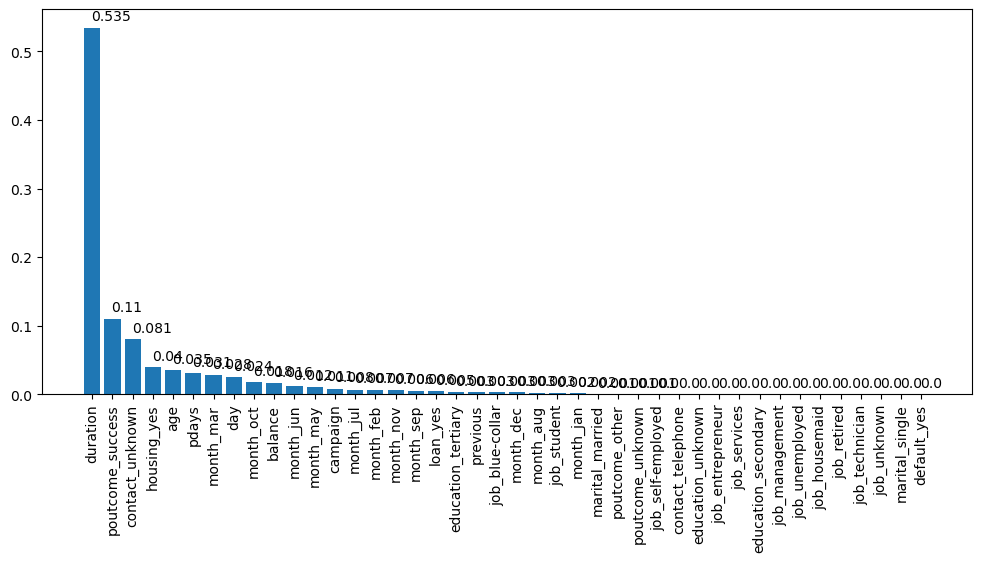

In [10]:
#модель 3: AdaBoost
print("Модель 3: AdaBoost Classifier")

start_time = time.time()

ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    random_state=42
)

ada_clf.fit(X_train, y_train)
train_time_ada = time.time() - start_time

print(f"Модель обучена. Время обучения: {train_time_ada:.2f} сек")


#модель 4: Gradient Boosting (градиентный бустинг)
print("Модель 4: Gradient Boosting Classifier")

start_time = time.time()

gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train, y_train)
train_time_gb = time.time() - start_time

print(f"Модель обучена. Время обучения: {train_time_gb:.2f} сек")

print("Важность признаков (Gradient Boosting)")
labels_gb, data_gb = draw_feature_importances(gb_clf, X_df, figsize=(12,5))



# 5) Оценка качества моделей и сравнение

Для оценки качества всех обученных моделей была использована тестовая выборка (20% данных, не участвовавших в обучении). В качестве основных метрик выбраны:

1. Accuracy-доля правильных ответов модели;
2. Precision-точность предсказания положительного класса (какая доля предсказанных «yes» действительно является «yes»);
3. Recall-полнота предсказания положительного класса (какая доля реальных «yes» была предсказана верно);
4. F1-score-гармоническое среднее между Precision и Recall, основная метрика для сравнения.

Результаты представлены в таблице и на столбчатой диаграмме. Дополнительно построены матрицы ошибок для каждой модели, позволяющие оценить количество верных и неверных предсказаний по каждому классу.
Наилучшей моделью по F1-score получился Random Forest (0.8552). Все модели показали достойное качество классификации. Методы бэггинга (Bagging и Random Forest) продемонстрировали наиболее стабильные результаты, AdaBoost показал наименьшее качество из-за чувствительности к выбросам, а Gradient Boosting в целом подтвердил свою эффективность.



Результаты оценки качества на тестовой выборке:
------------------------------------------------------------
Модель              Accuracy  Precision Recall    F1-score  
------------------------------------------------------------
Bagging             0.8562    0.8270    0.8809    0.8531    
Random Forest       0.8580    0.8276    0.8847    0.8552    
AdaBoost            0.8280    0.8247    0.8091    0.8168    
Gradient Boosting   0.8509    0.8298    0.8620    0.8456    
------------------------------------------------------------

Визуализация сравнения моделей:


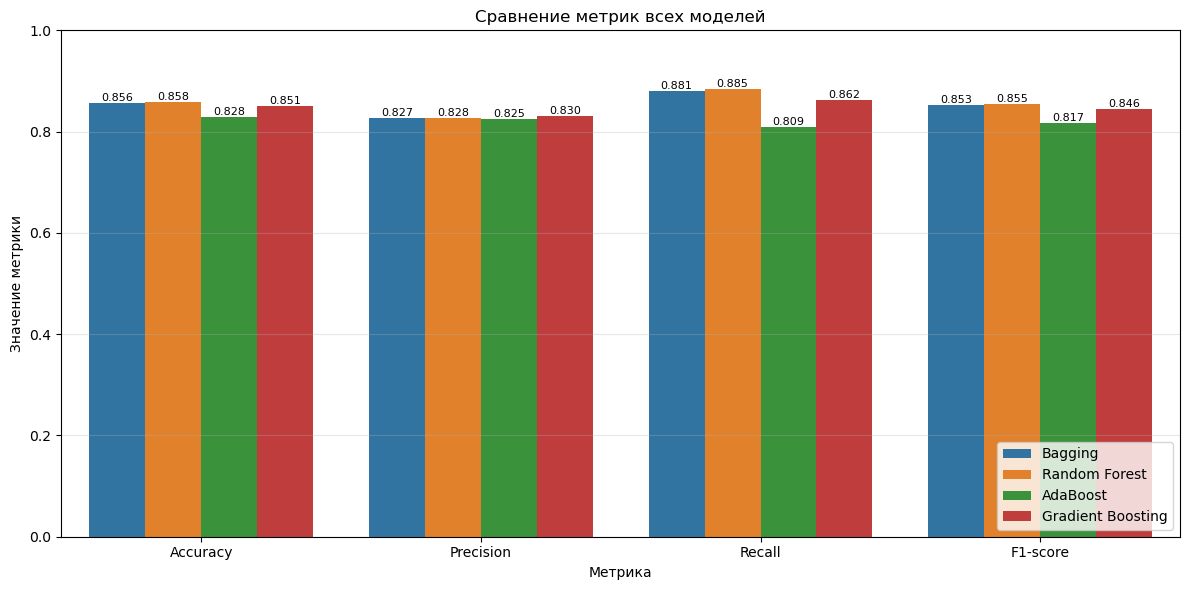

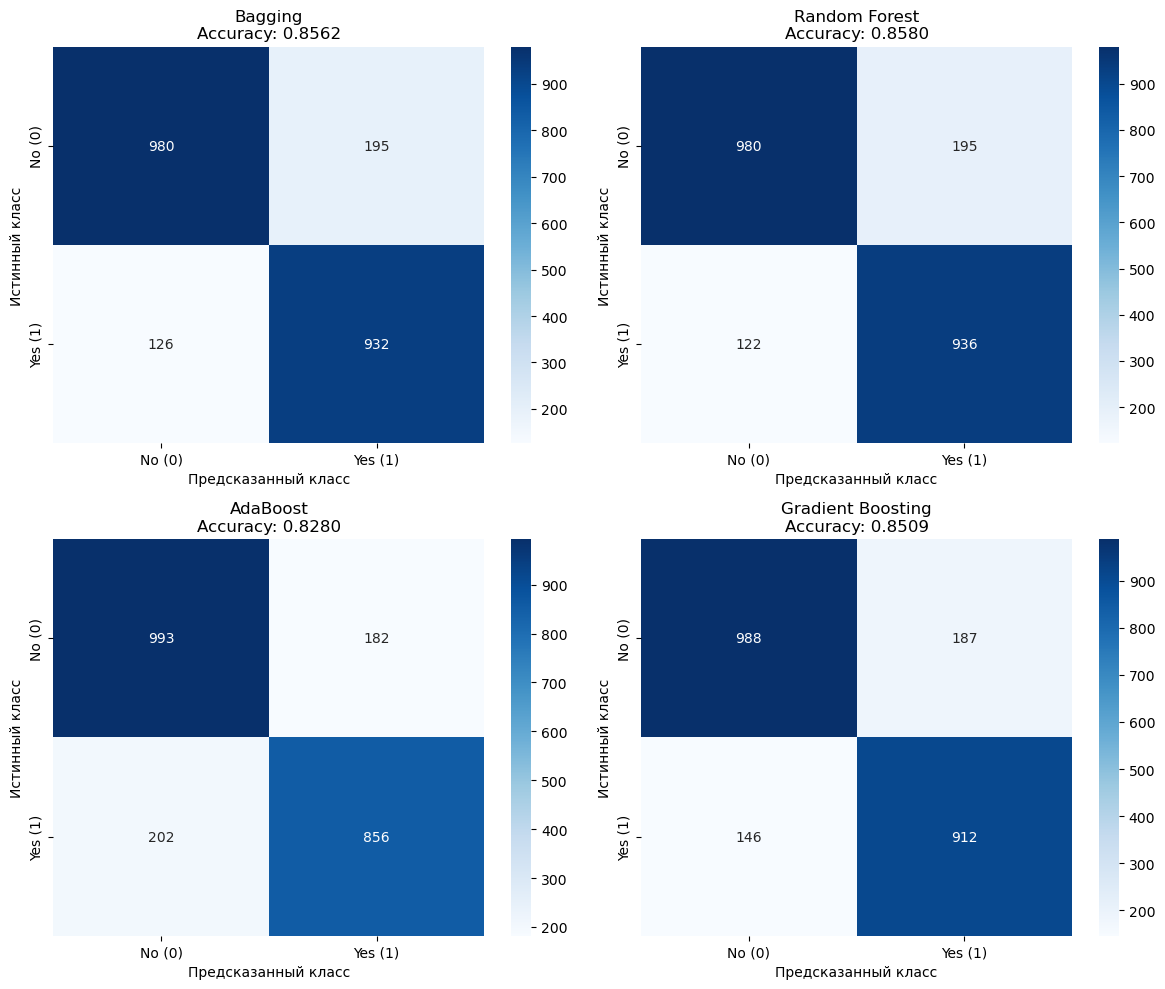


Наилучшая модель по F1-score: Random Forest (0.8552)


In [12]:
#словари для хранения результатов
results = {}
confusion_matrices = {}

#список моделей с предсказаниями
models = {
    'Bagging': bagging_clf,
    'Random Forest': rf_clf,
    'AdaBoost': ada_clf,
    'Gradient Boosting': gb_clf
}

#получаем предсказания для каждой модели
for name, model in models.items():
    y_pred = model.predict(X_test)
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred)
    }
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

#вывод результатов в виде таблицы
print("\nРезультаты оценки качества на тестовой выборке:")
print("-" * 60)
print(f"{'Модель':<20}{'Accuracy':<10}{'Precision':<10}{'Recall':<10}{'F1-score':<10}")
print("-" * 60)

for name in models.keys():
    r = results[name]
    print(f"{name:<20}{r['Accuracy']:<10.4f}{r['Precision']:<10.4f}{r['Recall']:<10.4f}{r['F1-score']:<10.4f}")

print("-" * 60)

#визуализация сравнения метрик
print("\nВизуализация сравнения моделей:")

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']

#создаем фрейм для удобства построения графика
data_for_plot = []
for name in models.keys():
    for metric in metrics_names:
        data_for_plot.append({
            'Модель': name,
            'Метрика': metric,
            'Значение': results[name][metric]
        })

df_plot = pd.DataFrame(data_for_plot)

#график сравнения метрик
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_plot, x='Метрика', y='Значение', hue='Модель', ax=ax)
ax.set_title('Сравнение метрик всех моделей')
ax.set_ylabel('Значение метрики')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

#подпись значений на столбцах
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()

#визуализация матриц ошибок
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No (0)', 'Yes (1)'], 
                yticklabels=['No (0)', 'Yes (1)'], ax=axes[i])
    axes[i].set_title(f'{name}\nAccuracy: {results[name]["Accuracy"]:.4f}')
    axes[i].set_ylabel('Истинный класс')
    axes[i].set_xlabel('Предсказанный класс')

plt.tight_layout()
plt.show()

#вывод наилучшей модели
best_model = max(results, key=lambda x: results[x]['F1-score'])
print(f"\nНаилучшая модель по F1-score: {best_model} ({results[best_model]['F1-score']:.4f})")



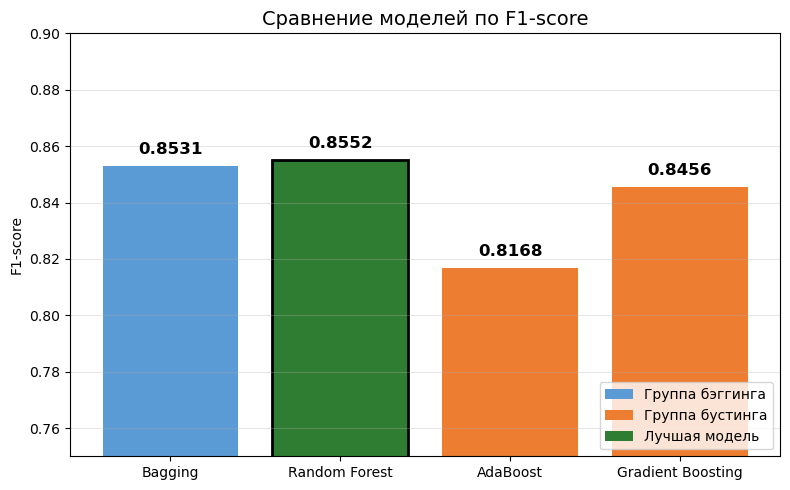

In [16]:
#только F1-score для наглядного сравнения
fig, ax = plt.subplots(figsize=(8, 5))
model_names = list(results.keys())
f1_scores = [results[m]['F1-score'] for m in model_names]
colors = ['#5B9BD5', '#5B9BD5', '#ED7D31', '#ED7D31']  # синие для бэггинга, оранжевые для бустинга

bars = ax.bar(model_names, f1_scores, color=colors)
ax.set_title('Сравнение моделей по F1-score', fontsize=14)
ax.set_ylabel('F1-score')
ax.set_ylim(0.75, 0.90)


for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{score:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

#выделяем лучшую модель
best_idx = model_names.index(best_model)
bars[best_idx].set_color('#2E7D32')
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(2)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#5B9BD5', label='Группа бэггинга'),
                   Patch(facecolor='#ED7D31', label='Группа бустинга'),
                   Patch(facecolor='#2E7D32', label='Лучшая модель')]
ax.legend(handles=legend_elements, loc='lower right')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод

В ходе выполнения лабораторной работы были изучены ансамблевые методы машинного обучения на примере задачи бинарной классификации с использованием датасета Bank Marketing. На этапе предобработки данные были очищены от пропусков, категориальные признаки закодированы методом One-Hot Encoding, а числовые признаки масштабированы с помощью StandardScaler. Выборка была разделена на обучающую и тестовую в соотношении 80/20 с сохранением баланса классов. Были обучены четыре ансамблевые модели: Bagging Classifier и Random Forest из группы методов бэггинга, а также AdaBoost Classifier и Gradient Boosting Classifier из группы методов бустинга. Оценка качества моделей проводилась по метрикам Accuracy, Precision, Recall и F1-score на тестовой выборке. Все модели показали высокое качество классификации, однако наилучший результат по основной метрике F1-score продемонстрировал случайный лес со значением 0.8552. Полученные результаты подтверждают эффективность ансамблевых методов для решения задач классификации.